In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
onwind_cf = pd.read_pickle('Wetterdaten/cappacity_factors_prepared/cf_onwind.pkl')
offwind_cf = pd.read_pickle('Wetterdaten/cappacity_factors_prepared/cf_offwind.pkl')
solar_cf = pd.read_pickle('Wetterdaten/cappacity_factors_prepared/cf_solar.pkl')
solar_hsat_diff = pd.read_pickle('Wetterdaten/cappacity_factors_prepared/diff_solar_to_solar-hsat.pkl')

In [9]:
np.random.seed(1)

choice = np.random.choice(np.arange(0, 50), 6, replace=False)

choice

array([27, 35, 40, 38,  2,  3])

In [19]:
for i in choice:
    print(onwind_cf[i].mean().values+offwind_cf[i].mean().values+2*solar_cf[i].mean().values)

[1.03056861]
[1.02860446]
[1.03314896]
[1.00890964]
[1.02773666]
[0.99796881]


In [41]:
df = pd.DataFrame(offwind_cf[35])
df2 = pd.DataFrame(offwind_cf[40])

df = df.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

df.iloc[:,0].corr(df2.iloc[:,0])

0.7754601576558172

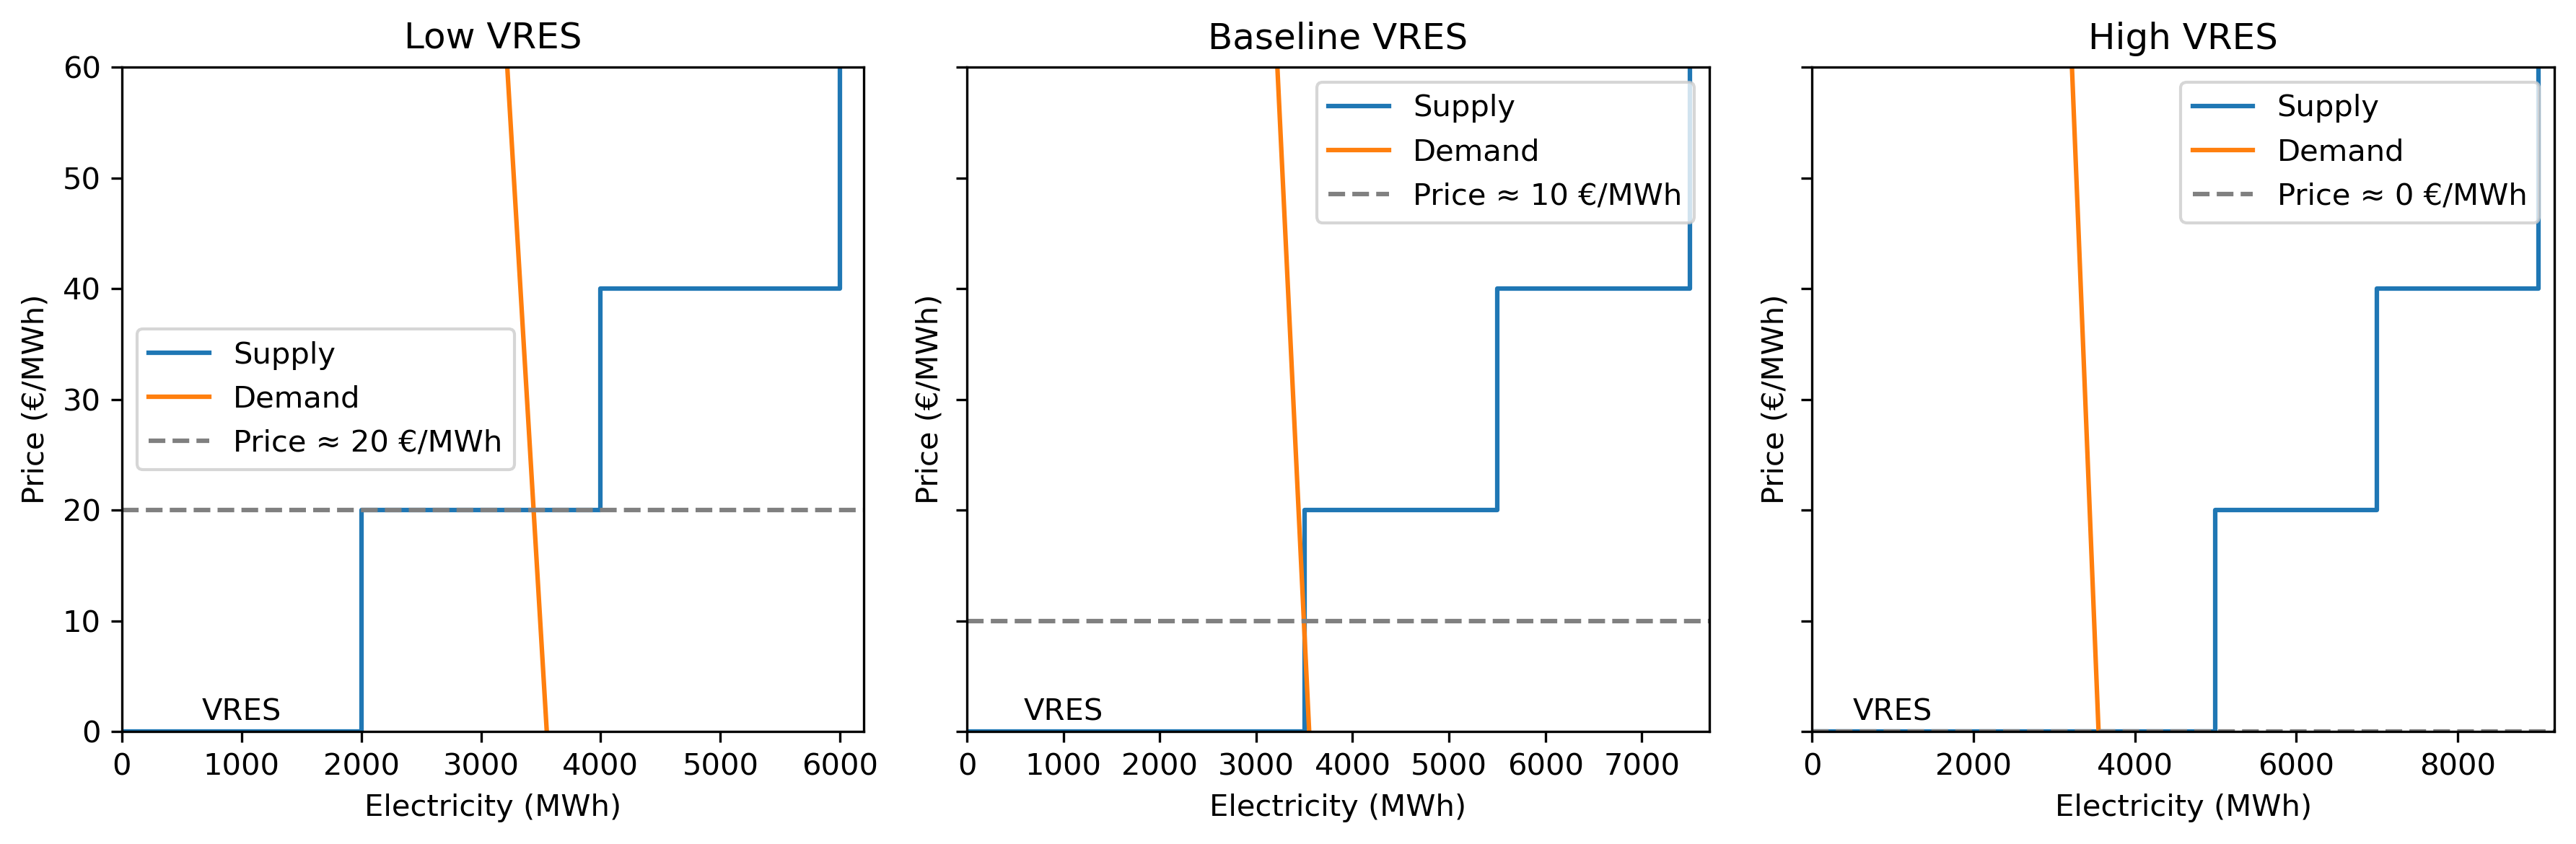

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def merit_order_plot(vres_capacity, lignite_capacity, coal_capacity, gas_capacity, ax, title, eq_price):
    # Grenzkosten in €/MWh
    costs = {
        "VRES": 0,
        "Lignite": 20,
        "Coal": 40,
        "Gas": 70
    }
    capacities = {
        "VRES": vres_capacity,
        "Lignite": lignite_capacity,
        "Coal": coal_capacity,
        "Gas": gas_capacity
    }
    
    # Sortierte Merit Order
    order = sorted(costs.items(), key=lambda x: x[1])
    
    # Angebotskurve vorbereiten
    x = [0]
    y = [0]
    cumulative = 0
    for tech, cost in order:
        cumulative += capacities[tech]
        x.extend([cumulative, cumulative])
        y.extend([cost, cost])
    
    ax.step(x, y, where="post",label="Supply")
    
    
    # Nachfrage-Kurve: bei 100€/MWh -> 3000 MW, bei 0€/MWh -> 3550 MW
    demand_curve_y = np.linspace(0, 100, 200)
    demand_curve_x = 3550 - 5.5 * demand_curve_y
    ax.plot(demand_curve_x, demand_curve_y, label="Demand")
    
    # Horizontale Linie am Gleichgewichtspreis
    ax.axhline(eq_price, color="grey", linestyle="--", label=f"Price ≈ {eq_price} €/MWh")
    
    # Achsenlimits
    ax.set_ylim(0, 60)  # Preis nur bis 60 €/MWh
    ax.set_xlim(0, cumulative + 200)  # etwas Platz rechts
    
    ax.set_title(title)
    ax.set_xlabel("Electricity (MWh)")
    ax.set_ylabel("Price (€/MWh)")
    ax.legend()

# Szenarien (Less, Basic, More)
fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True, dpi=300)

merit_order_plot(1000, 1000, 2000, 2000, axes[0], "Low VRES", 20)

axes[0].text(1000, 1, 'VRES', ha='center')
axes[1].text(1000, 1, 'VRES', ha='center')
axes[2].text(1000, 1, 'VRES', ha='center')
merit_order_plot(2500, 1000, 2000, 2000, axes[1], "Baseline VRES", 10)
merit_order_plot(4000, 1000, 2000, 2000, axes[2], "High VRES", 0)

plt.tight_layout()
plt.show()
